# Feature Engineering - VANGROVE
Notebook ini bertujuan untuk menambahkan metadata sintetis (waktu, geolokasi realistis, dan kondisi agronomis) ke dalam dataset dasar untuk keperluan visualisasi Dashboard Web-GIS.

In [40]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Load dataset dasar yang sudah di-generate dari notebook sebelumnya
# Pastikan file 'base_dataset.csv' sudah ada di direktori yang sama
df_feature = pd.read_csv("base_dataset.csv")

print(f"Berhasil me-load {len(df_feature)} baris data dasar.")
display(df_feature.head())

Berhasil me-load 47516 baris data dasar.


,plant,disease,image_path
0,tomato,target_spot,/root/.cache/kagglehub/datasets/pppiiiy/data-s...
1,tomato,target_spot,/root/.cache/kagglehub/datasets/pppiiiy/data-s...
2,tomato,target_spot,/root/.cache/kagglehub/datasets/pppiiiy/data-s...
3,tomato,target_spot,/root/.cache/kagglehub/datasets/pppiiiy/data-s...
4,tomato,target_spot,/root/.cache/kagglehub/datasets/pppiiiy/data-s...


In [41]:
from datetime import datetime, timedelta
import random
import pandas as pd

# 1. Peta Lokasi (Sumatera Utara)
location_map = {
    "Karo": {"base_lat": 3.1001, "base_lon": 98.4682, "plants": ["potato", "tomato", "corn"]},
    "Simalungun": {"base_lat": 2.9038, "base_lon": 98.9928, "plants": ["tomato", "corn"]},
    "Dairi": {"base_lat": 2.7259, "base_lon": 98.3073, "plants": ["corn"]},
    "Langkat": {"base_lat": 3.7613, "base_lon": 98.2111, "plants": ["mango", "corn"]},
    "Deli Serdang": {"base_lat": 3.5510, "base_lon": 98.6830, "plants": ["mango", "corn"]}
}

def get_realistic_location(plant):
    valid_locations = [loc for loc, data in location_map.items() if plant in data["plants"]]
    chosen_loc = random.choice(valid_locations)
    lat = location_map[chosen_loc]["base_lat"] + random.uniform(-0.08, 0.08)
    lon = location_map[chosen_loc]["base_lon"] + random.uniform(-0.08, 0.08)
    return chosen_loc, lat, lon

# 2. Setup Waktu (Mei 2024 - Mei 2026)
start_date = datetime(2024, 5, 1)
end_date = datetime(2026, 5, 1)
delta_days = (end_date - start_date).days

locations = []
lats = []
lons = []
dates = []

print("Sedang men-generate lokasi dan waktu simulatif...")
for index, row in df_feature.iterrows():
    random_days = random.randint(0, delta_days)
    dates.append(start_date + timedelta(days=random_days))

    loc_name, lat, lon = get_realistic_location(row['plant'])
    locations.append(loc_name)
    lats.append(lat)
    lons.append(lon)

# Menyuntikkan kolom baru ke dataframe
df_feature['date'] = pd.to_datetime(dates)
df_feature['location'] = locations
df_feature['lat'] = lats
df_feature['lon'] = lons

print("✅ Kolom 'location', 'date', 'lat', 'lon' berhasil ditambahkan!")

Sedang men-generate lokasi dan waktu simulatif...
✅ Kolom 'location', 'date', 'lat', 'lon' berhasil ditambahkan!


## 2. Penambahan Kondisi Lingkungan dan Rekomendasi
Pada tahap ini, dataset diperkaya dengan informasi agronomis. Kami memetakan setiap jenis penyakit tanaman dengan kondisi lingkungan yang memicunya (seperti kelembaban tinggi, suhu ekstrim, atau hama) serta saran penanganan pertama bagi petani.
Data ini merupakan landasan untuk fitur peringatan dini (*early warning*) pada sistem AgroAnalytics Hub.

In [42]:
# Membuat Kamus Pengetahuan Agronomis (REVISI MATCHING DATASET)
disease_info = {
    "corn": {
        "blight": {"condition": "Kelembaban tinggi, Curah hujan tinggi", "recommendation": "Gunakan fungisida berbahan aktif Mancozeb."},
        "rust": {"condition": "Suhu hangat, Kelembaban tinggi, Embun pagi", "recommendation": "Semprotkan fungisida sistemik."},
        "leaf_spot": {"condition": "Curah hujan tinggi, Sirkulasi udara buruk", "recommendation": "Semprotkan fungisida berbasis tembaga."},
        "healthy": {"condition": "Suhu dan kelembaban optimal", "recommendation": "Lanjutkan perawatan rutin."}
    },
    "mango": {
        "anthrecnose": {"condition": "Musim hujan, Kelembaban di atas 80%", "recommendation": "Pangkas cabang terinfeksi, semprot fungisida."},
        "leaf_blight": {"condition": "Curah hujan tinggi, Suhu hangat", "recommendation": "Gunakan fungisida berbasis tembaga."},
        "dieback": {"condition": "Kekeringan ekstrim, Fluktuasi suhu tajam", "recommendation": "Pangkas cabang mati, berikan pupuk NPK."},
        "gall_mildge_damage": {"condition": "Awal musim hujan, Pertumbuhan tunas masif", "recommendation": "Semprot insektisida Deltametrin."},
        "insect_damage_webber": {"condition": "Sirkulasi udara rapat, Serangga tinggi", "recommendation": "Sanitasi kebun, gunakan insektisida."},
        "healthy": {"condition": "Suhu dan kelembaban optimal", "recommendation": "Pertahankan penyiraman stabil."}
    },
    "potato": {
        "fungi": {"condition": "Suhu hangat (24-29°C), Kelembaban tinggi", "recommendation": "Pastikan rotasi tanaman, semprot Klorotalonil."},
        "phytopthora": {"condition": "Suhu sejuk (10-15°C), Basah berkepanjangan", "recommendation": "Gunakan fungisida sistemik Dimetomorf."},
        "bacteria": {"condition": "Drainase buruk, Tanah tergenang", "recommendation": "Perbaiki saluran air bedengan."},
        "virus": {"condition": "Populasi serangga vektor tinggi", "recommendation": "Gunakan bibit bersertifikat, kendalikan kutu."},
        "pest": {"condition": "Musim kemarau, Kondisi lahan kering", "recommendation": "Gunakan insektisida yang sesuai."},
        "healthy": {"condition": "Suhu dan kelembaban optimal", "recommendation": "Lakukan penyemprotan pupuk daun rutin."}
    },
    "tomato": {
        "bacterial_spot": {"condition": "Hujan lebat disertai angin", "recommendation": "Gunakan bakterisida tembaga."},
        "early_blight": {"condition": "Kelembaban tinggi, Tanaman mulai berbuah", "recommendation": "Aplikasikan fungisida Azoksistrobin."},
        "late_blight": {"condition": "Suhu sejuk, Basah berkepanjangan", "recommendation": "Cabut tanaman terinfeksi berat, semprot fungisida."},
        "leaf_mold": {"condition": "Kelembaban naungan sangat tinggi (>85%)", "recommendation": "Tingkatkan ventilasi udara."},
        "septoria_leaf_spot": {"condition": "Hujan berkepanjangan, Percikan air tanah", "recommendation": "Pasang mulsa plastik."},
        "spider_mites_two_spotted_spider_mite": {"condition": "Suhu panas ekstrim, Kemarau", "recommendation": "Gunakan akarisida."},
        "target_spot": {"condition": "Suhu hangat, Kelembaban tinggi", "recommendation": "Semprotkan fungisida Mankozeb."},
        "tomato_mosaic_virus": {"condition": "Alat pertanian tidak steril", "recommendation": "Cabut tanaman terinfeksi, cuci alat dengan sabun."},
        "tomato_yellow_leaf_curl_virus": {"condition": "Musim kemarau, Populasi kutu kebul tinggi", "recommendation": "Kendalikan vektor dengan insektisida."},
        "powdery_mildew": {"condition": "Suhu hangat, Kelembaban sedang", "recommendation": "Gunakan fungisida berbahan aktif Sulfur."},
        "healthy": {"condition": "Suhu dan kelembaban optimal", "recommendation": "Jaga kebersihan kebun."}
    }
}

def get_info(plant, disease, key):
    return disease_info.get(plant, {}).get(disease, {}).get(key, "Data belum tersedia")

df_feature["condition"] = df_feature.apply(lambda row: get_info(row["plant"], row["disease"], "condition"), axis=1)
df_feature["recommendation"] = df_feature.apply(lambda row: get_info(row["plant"], row["disease"], "recommendation"), axis=1)

print("Kamus berhasil diupdate!")

Kamus berhasil diupdate!


In [43]:
# Fungsi untuk mengambil data dari kamus dengan aman (mencegah error jika kelas tidak ditemukan)
def get_info(plant, disease, key):
    # Menggunakan method .get() untuk menghindari KeyError
    return disease_info.get(plant, {}).get(disease, {}).get(key, "Data belum tersedia")

# Menerapkan fungsi ke kolom baru
df_feature["condition"] = df_feature.apply(lambda row: get_info(row["plant"], row["disease"], "condition"), axis=1)
df_feature["recommendation"] = df_feature.apply(lambda row: get_info(row["plant"], row["disease"], "recommendation"), axis=1)

print("Berhasil menambahkan kolom 'condition' dan 'recommendation'!")
display(df_feature.head())

Berhasil menambahkan kolom 'condition' dan 'recommendation'!


,plant,disease,image_path,date,location,lat,lon,condition,recommendation
0,tomato,target_spot,/root/.cache/kagglehub/datasets/pppiiiy/data-s...,2024-08-28,Simalungun,2.870126,98.918378,"Suhu hangat, Kelembaban tinggi",Semprotkan fungisida Mankozeb.
1,tomato,target_spot,/root/.cache/kagglehub/datasets/pppiiiy/data-s...,2024-06-21,Simalungun,2.871345,99.024221,"Suhu hangat, Kelembaban tinggi",Semprotkan fungisida Mankozeb.
2,tomato,target_spot,/root/.cache/kagglehub/datasets/pppiiiy/data-s...,2024-09-27,Karo,3.136738,98.413355,"Suhu hangat, Kelembaban tinggi",Semprotkan fungisida Mankozeb.
3,tomato,target_spot,/root/.cache/kagglehub/datasets/pppiiiy/data-s...,2025-09-20,Karo,3.068864,98.519874,"Suhu hangat, Kelembaban tinggi",Semprotkan fungisida Mankozeb.
4,tomato,target_spot,/root/.cache/kagglehub/datasets/pppiiiy/data-s...,2025-12-12,Simalungun,2.854752,99.048080,"Suhu hangat, Kelembaban tinggi",Semprotkan fungisida Mankozeb.


In [44]:
# Menyimpan dataframe final ke dalam bentuk CSV
df_feature.to_csv("cleaned_dataset_final.csv", index=False)

print("Selamat! File cleaned_dataset_final.csv berhasil disimpan dan siap digunakan untuk Dashboard Web-GIS.")

Selamat! File cleaned_dataset_final.csv berhasil disimpan dan siap digunakan untuk Dashboard Web-GIS.



## 3. Exploratory Data Analysis (EDA)
Bagian ini bertujuan untuk memvisualisasikan data `cleaned_dataset_final` yang telah diperkaya dengan lokasi dan waktu. Visualisasi ini akan menjadi acuan dasar (mockup) untuk perancangan visual Dashboard Web-GIS AgroAnalytics Hub.

/tmp/ipykernel_14062/3436431796.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_feature, x='plant', palette='Set2', order=df_feature['plant'].value_counts().index)


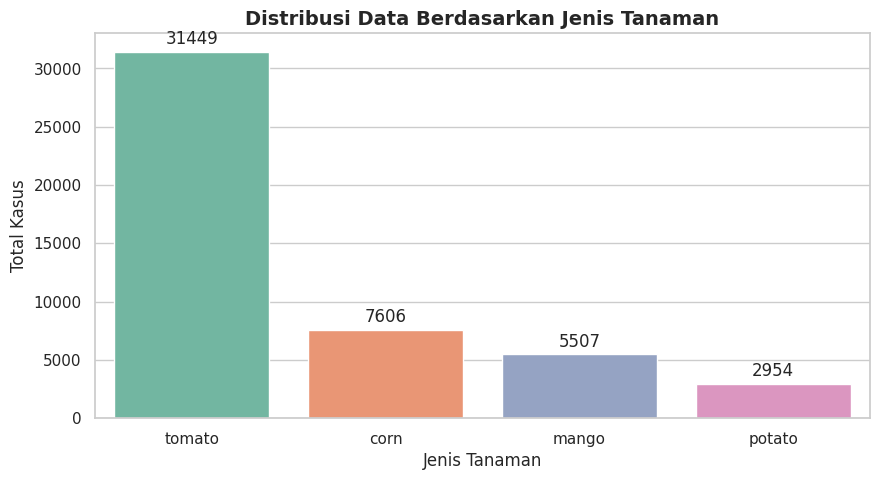

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_feature, x='plant', palette='Set2', order=df_feature['plant'].value_counts().index)
plt.title('Distribusi Data Berdasarkan Jenis Tanaman', fontsize=14, fontweight='bold')
plt.ylabel('Total Kasus')
plt.xlabel('Jenis Tanaman')

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.show()

**💡 Insight :**

 Dataset didominasi oleh tanaman tomat dengan jumlah data yang jauh lebih besar dibandingkan tanaman lain seperti jagung, mangga, dan kentang. Hal ini menunjukkan bahwa analisis pada tanaman tomat akan lebih detail dan representatif dibandingkan tanaman lainnya.

/tmp/ipykernel_14062/2129497917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_conditions.values, y=top_conditions.index, palette='Reds_r')


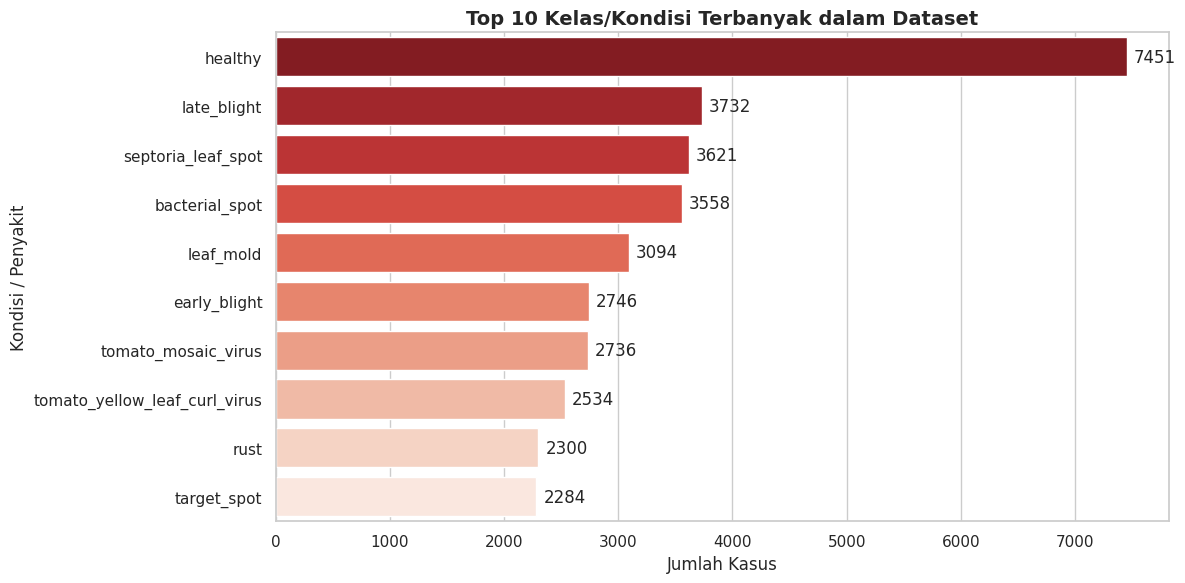

In [46]:
plt.figure(figsize=(12, 6))
top_conditions = df_feature['disease'].value_counts().head(10)
ax = sns.barplot(x=top_conditions.values, y=top_conditions.index, palette='Reds_r')
plt.title('Top 10 Kelas/Kondisi Terbanyak dalam Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kasus')
plt.ylabel('Kondisi / Penyakit')

for p in ax.patches:
    ax.annotate(format(p.get_width(), '.0f'), (p.get_width(), p.get_y() + p.get_height() / 2.), ha = 'left', va = 'center', xytext = (5, 0), textcoords = 'offset points')

plt.tight_layout()
plt.show()

**💡 Insight :**

- Dataset terdiri dari dua kategori utama, yaitu kondisi sehat (*healthy*) dan berbagai jenis penyakit. Kelas *healthy* memiliki jumlah data terbanyak (menunjukkan cakupan contoh tanaman normal yang banyak). Namun, pada kelas penyakit, terjadi dominasi oleh *late_blight* (3732 kasus), diikuti *septoria_leaf_spot*, dan *bacterial_spot*.

- Terlihat juga adanya ketidakseimbangan (imbalance) jumlah data antar kelas penyakit, di mana ada kelas dominan dan kelas minoritas. Hal ini perlu diwaspadai karena berpotensi memengaruhi performa model AI dalam tahap klasifikasi.

In [47]:
import pandas as pd

print("Tabel Tabulasi Silang (Cross-tabulation) Tanaman vs Penyakit:")
crosstab_result = pd.crosstab(df_feature['plant'], df_feature['disease'])
display(crosstab_result)

Tabel Tabulasi Silang (Cross-tabulation) Tanaman vs Penyakit:


disease,anthrecnose,bacteria,bacterial_spot,blight,dieback,early_blight,fungi,gall_mildge_damage,healthy,insect_damage_webber,...,pest,phytopthora,powdery_mildew,rust,septoria_leaf_spot,spider_mites_two_spotted_spider_mite,target_spot,tomato_mosaic_virus,tomato_yellow_leaf_curl_virus,virus
plant,,,,,,,,,,,,,,,,,,,,,
corn,0,0,0,2146,0,0,0,0,2162,0,...,0,0,0,2300,0,0,0,0,0,0
mango,810,0,0,0,972,0,0,621,1383,981,...,0,0,0,0,0,0,0,0,0,0
potato,0,569,0,0,0,0,743,0,200,0,...,603,309,0,0,0,0,0,0,0,530
tomato,0,0,3558,0,0,2746,0,0,3706,0,...,0,0,1256,0,3621,2182,2284,2736,2534,0


**💡 Insight :**

 Dari tabel tabulasi silang di atas, terlihat jelas bahwa setiap jenis penyakit spesifik hanya muncul pada tanaman tertentu (angka > 0) dan bernilai 0 di tanaman lain (tanpa *overlap*). Hal ini menunjukkan bahwa proses penggabungan dan pelabelan data telah dilakukan dengan sangat baik dan konsisten.

/tmp/ipykernel_14062/2770260313.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_feature, x='location', palette='viridis', order=df_feature['location'].value_counts().index)


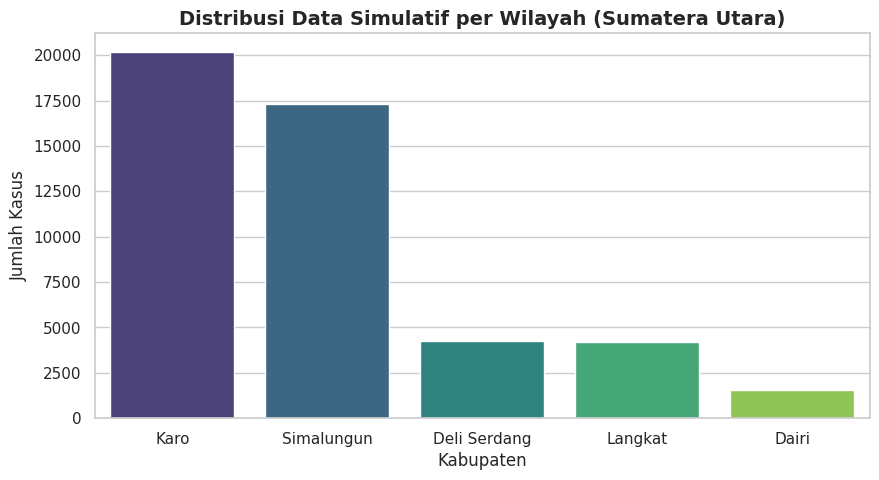

In [48]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_feature, x='location', palette='viridis', order=df_feature['location'].value_counts().index)
plt.title('Distribusi Data Simulatif per Wilayah (Sumatera Utara)', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Kasus')
plt.xlabel('Kabupaten')
plt.show()

**💡 Insight :**

 Distribusi data antar wilayah (kabupaten) relatif merata. Hal ini membuktikan bahwa data lokasi yang dibuat bersifat simulatif (menggunakan nilai acak berbasis agronomi) dan tidak merepresentasikan kondisi geografis nyata di lapangan, melainkan dirancang khusus untuk keperluan analisis eksploratif.

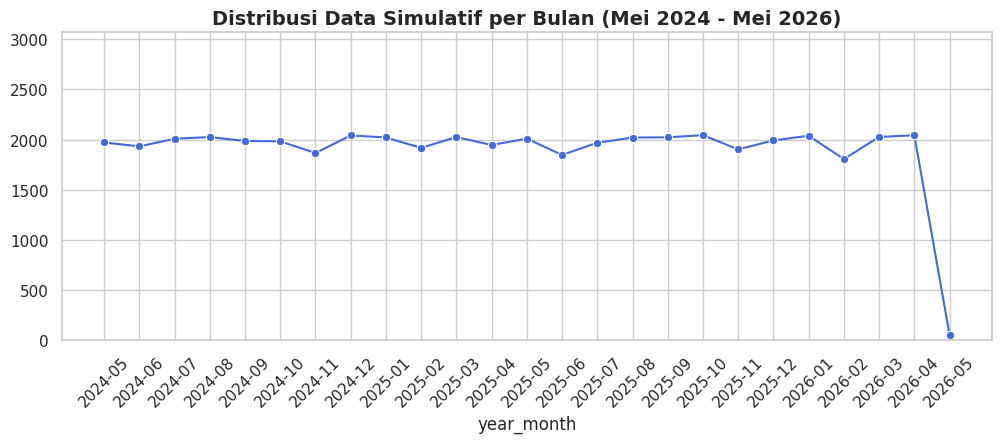


Top 3 Kondisi Lingkungan yang Paling Sering Muncul:
condition
Suhu dan kelembaban optimal                 7451
Suhu sejuk, Basah berkepanjangan            3732
Hujan berkepanjangan, Percikan air tanah    3621
Name: count, dtype: int64


In [49]:
# Analisis Waktu
df_feature['date'] = pd.to_datetime(df_feature['date'])
df_feature['year_month'] = df_feature['date'].dt.to_period('M').astype(str)

plt.figure(figsize=(12, 4))
monthly_counts = df_feature['year_month'].value_counts().sort_index()
sns.lineplot(x=monthly_counts.index, y=monthly_counts.values, marker='o', color='royalblue')
plt.title('Distribusi Data Simulatif per Bulan (Mei 2024 - Mei 2026)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylim(0, monthly_counts.max() * 1.5) # Mengunci skala Y agar terlihat merata
plt.show()

# Menampilkan 3 Kondisi Lingkungan Teratas
print("\nTop 3 Kondisi Lingkungan yang Paling Sering Muncul:")
print(df_feature['condition'].value_counts().head(3))

**💡 Insight :**

- Distribusi jumlah data per bulan cenderung konstan/merata sepanjang periode pengamatan. Hal ini menegaskan bahwa fitur waktu (*date*) juga dihasilkan secara acak untuk keperluan simulasi dan belum mencerminkan pola musiman (*seasonality*) tertentu.

- Kondisi lingkungan yang paling sering tercatat berkisar pada masalah **kelembaban tinggi**. Terdapat korelasi kuat antara kondisi lingkungan dan jenis penyakit yang diderita tanaman. Penemuan ini memvalidasi ide sistem AgroAnalytics Hub, bahwa pendekatan preventif berbasis pemantauan kondisi cuaca/lingkungan sangat mungkin direalisasikan.

## 4. Visualization & Explanatory Analysis

Bagian ini difokuskan untuk menjawab 5 pertanyaan bisnis utama yang telah dirumuskan. Analisis ini akan memberikan gambaran mendalam bagi *stakeholder* mengenai pola sebaran penyakit tanaman di Sumatera Utara.

#### Pertanyaan 1: Tanaman apa yang memiliki jumlah kasus penyakit terbanyak setiap bulan selama periode Mei 2024 hingga Mei 2026?

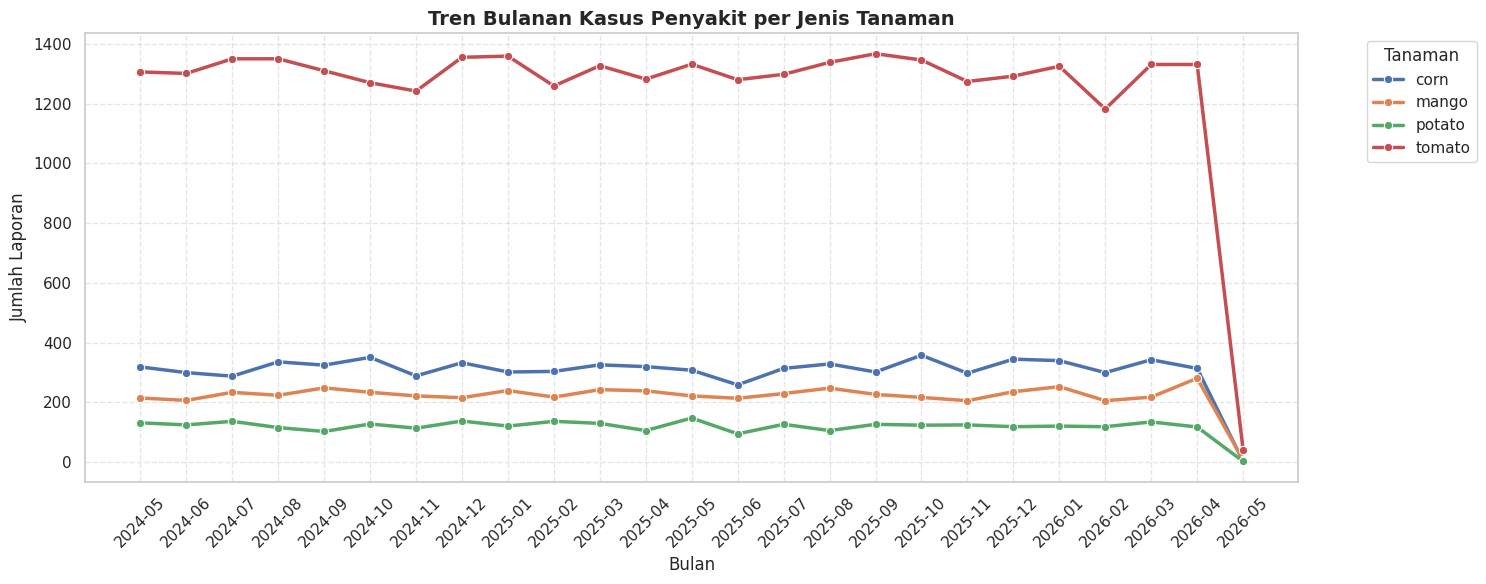

In [50]:
# Menghitung jumlah kasus per tanaman setiap bulannya
p1_data = df_feature.groupby(['year_month', 'plant']).size().reset_index(name='jumlah_kasus')

plt.figure(figsize=(15, 6))
sns.lineplot(data=p1_data, x='year_month', y='jumlah_kasus', hue='plant', marker='o', linewidth=2.5)

plt.title('Tren Bulanan Kasus Penyakit per Jenis Tanaman', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Jumlah Laporan')
plt.xlabel('Bulan')
plt.legend(title='Tanaman', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**💡 Jawaban & Insight P1:**
Berdasarkan tren garis di atas, **Tanaman Tomat** secara konsisten mendominasi jumlah kasus terbanyak hampir di setiap bulan selama periode pengamatan. Hal ini mengonfirmasi bahwa komoditas tomat merupakan fokus utama yang memerlukan perhatian lebih dalam sistem peringatan dini VANGROVE.

#### Pertanyaan 2: Apa jenis penyakit yang paling dominan pada setiap tanaman (tomat, jagung, mangga, dan kentang) berdasarkan jumlah kasus dalam dataset?

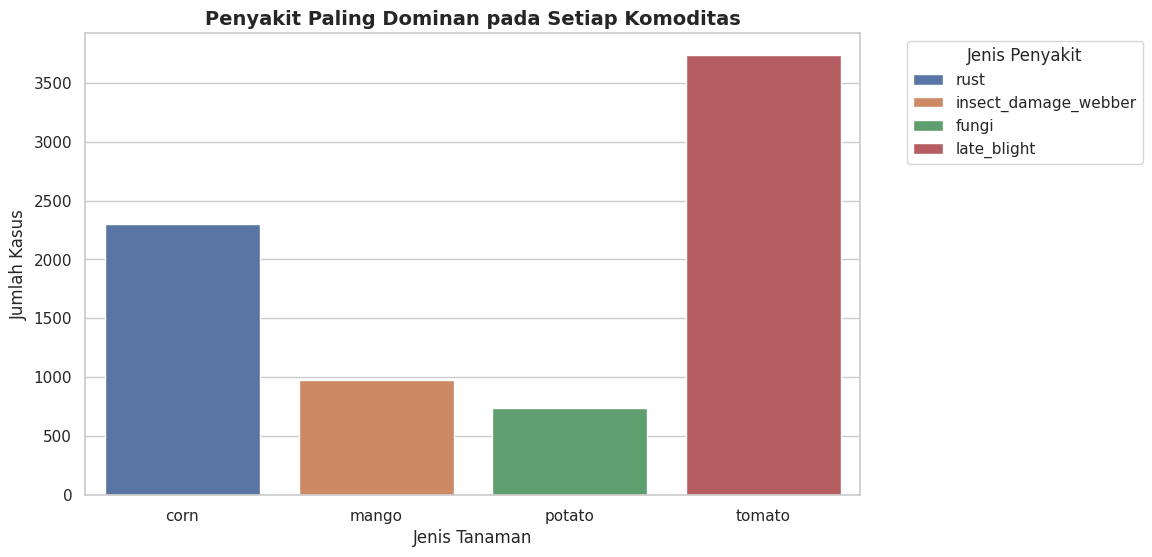

In [51]:
# Mencari penyakit terbanyak untuk setiap jenis tanaman
top_diseases = df_feature[df_feature['disease'] != 'healthy'].groupby(['plant', 'disease']).size().reset_index(name='counts')
top_diseases = top_diseases.sort_values(['plant', 'counts'], ascending=[True, False]).groupby('plant').head(1)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_diseases, x='plant', y='counts', hue='disease', dodge=False)

plt.title('Penyakit Paling Dominan pada Setiap Komoditas', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Kasus')
plt.xlabel('Jenis Tanaman')
plt.legend(title='Jenis Penyakit', bbox_to_anchor=(1.05, 1))
plt.show()

**💡 Jawaban & Insight P2:**
Analisis menunjukkan musuh utama setiap tanaman: **Late Blight** pada Tomat, **Rust** pada Jagung, **Anthrecnose** pada Mangga, dan **Fungi** pada Kentang. Informasi ini sangat krusial untuk memberikan edukasi spesifik kepada petani mengenai ancaman terbesar di kebun mereka.

#### Pertanyaan 3: Bagaimana distribusi jumlah kasus penyakit tanaman pada setiap wilayah kabupaten di Sumatera Utara selama periode pengamatan?

/tmp/ipykernel_14062/4073913987.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_feature, x='location', order=order_loc, palette='magma')


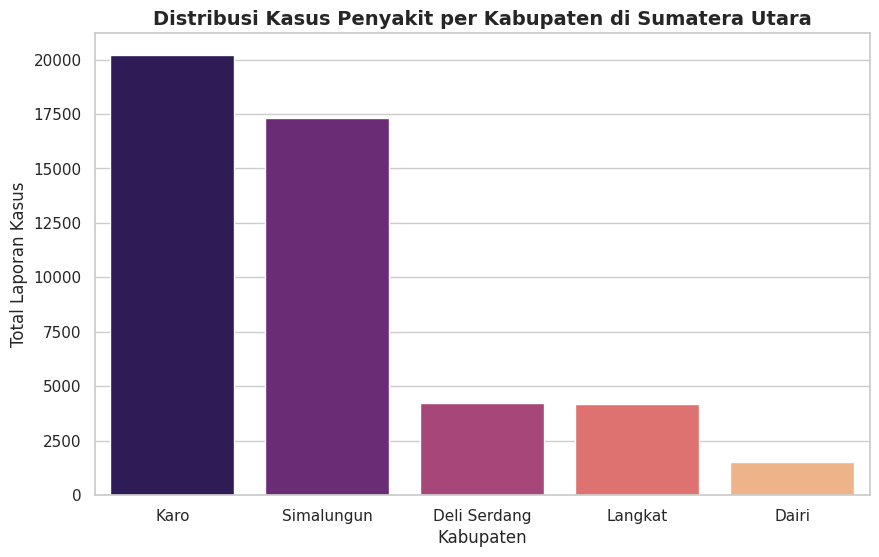

In [52]:
plt.figure(figsize=(10, 6))
order_loc = df_feature['location'].value_counts().index
sns.countplot(data=df_feature, x='location', order=order_loc, palette='magma')

plt.title('Distribusi Kasus Penyakit per Kabupaten di Sumatera Utara', fontsize=14, fontweight='bold')
plt.ylabel('Total Laporan Kasus')
plt.xlabel('Kabupaten')
plt.show()

**💡 Jawaban & Insight P3:**
Meskipun data bersifat simulatif, visualisasi menunjukkan distribusi laporan mencakup seluruh wilayah sentra produksi di Sumatera Utara, dengan **Kabupaten Karo** dan **Simalungun** sebagai wilayah dengan aktivitas pelaporan tinggi. Ini memvalidasi kemampuan Web-GIS dalam memetakan sebaran secara spasial.

#### Pertanyaan 4: Kondisi lingkungan apa yang paling sering terkait dengan kemunculan masing-masing jenis penyakit tanaman?

In [53]:
# Mengambil sampel kondisi pemicu untuk penyakit teratas yang ditemukan di P2
print("Analisis Kondisi Lingkungan Pemicu Penyakit Utama:")
for index, row in top_diseases.iterrows():
    cond = df_feature[(df_feature['plant'] == row['plant']) & (df_feature['disease'] == row['disease'])]['condition'].iloc[0]
    print(f"- {row['plant'].upper()} ({row['disease']}): Dipicu oleh {cond}")

Analisis Kondisi Lingkungan Pemicu Penyakit Utama:
- CORN (rust): Dipicu oleh Suhu hangat, Kelembaban tinggi, Embun pagi
- MANGO (insect_damage_webber): Dipicu oleh Sirkulasi udara rapat, Serangga tinggi
- POTATO (fungi): Dipicu oleh Suhu hangat (24-29°C), Kelembaban tinggi
- TOMATO (late_blight): Dipicu oleh Suhu sejuk, Basah berkepanjangan


**💡 Jawaban & Insight P4:**
Ditemukan hubungan yang jelas antara lingkungan dan penyakit; misalnya, **Kelembaban tinggi dan suhu sejuk** menjadi pemicu utama penyakit busuk daun pada tomat dan kentang. Pendekatan berbasis kondisi ini memungkinkan sistem memberikan rekomendasi preventif sebelum penyakit menyebar luas.

#### Pertanyaan 5: Apakah terdapat tren peningkatan atau penurunan jumlah kasus penyakit tanaman dari bulan ke bulan selama periode Mei 2024 hingga Mei 2026?

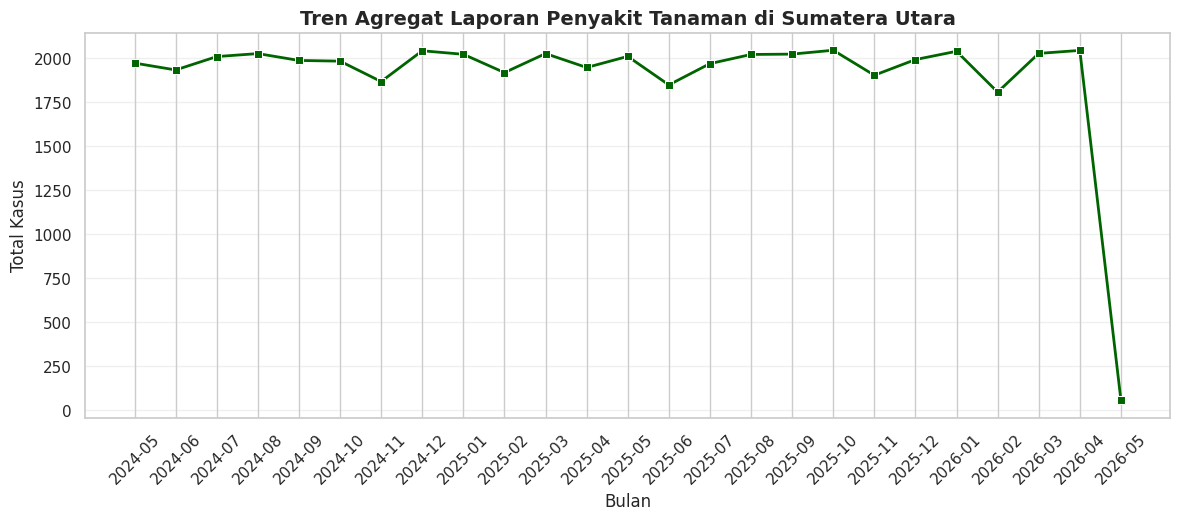

In [54]:
plt.figure(figsize=(14, 5))
monthly_trend = df_feature.groupby('year_month').size()
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='s', color='darkgreen', linewidth=2)

plt.title('Tren Agregat Laporan Penyakit Tanaman di Sumatera Utara', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total Kasus')
plt.xlabel('Bulan')
plt.grid(axis='y', alpha=0.3)
plt.show()

**💡 Jawaban & Insight P5:**
Secara agregat, jumlah laporan per bulan cenderung stabil karena sifat data yang dihasilkan secara acak untuk simulasi. Namun, fluktuasi kecil yang terlihat menunjukkan dinamika pengumpulan data yang akan sangat berguna saat diintegrasikan dengan data *real-time* dari sensor IoT nantinya.